# **Directed percolation in Rust-Python**

Demo simulation of directed percolation on a 2d lattice.

<hr>

## Preliminaries

In [1]:
from essentials import *
dprs.__version__

'2026.4.21'

<hr>

## Parameters

In [2]:
do_central_seed: bool = False

# p_c: float = 0.160155   # old SimplifiedDomanyKinzel
# p_c: float = 0.20403    # new SimplifiedDomanyKinzel
# p_c: float = 0.4031028  # old StaggeredDomanyKinzel
p_c: float = 0.344555
if do_central_seed:
    growth_model = GrowthModel.DomanyKinzel
    growth_scheme = GrowthScheme.Staggered
    n_xy: int = 500
    n_iterations: int = 8_000
    sample_period: int = 1
    initial_condition = InitialCondition.CentralCell
    # random_seed: int = 23
    # p_1: float = p_c + 0.01
    random_seed: int = 34
    p_1: float = p_c + 0.001
    p_2: float = p_1
else:
    growth_model = GrowthModel.DomanyKinzel
    growth_scheme = GrowthScheme.Staggered
    n_xy: int = 5_000
    n_iterations: int = 5_000
    sample_period: int = 0
    initial_condition = InitialCondition.Randomized
    p_1: float = p_c
    p_2: float = p_1
    random_seed: int = 1
# Just in case we forget to update sample_period to match n_iterations
if sample_period > n_iterations:
    sample_period = n_iterations

In [3]:
class Parameters:
    growth_model = growth_model
    growth_scheme = growth_scheme
    dim = Dimension.D2
    n_x: int = n_xy
    n_y: int = n_xy
    n_z: int = 1
    p_1: float = p_1
    p_2: float = p_2
    p_conj: float = 0
    p_nbr: float = 0.5
    p_diag: float = 0.5
    u_x: float = 0.0
    n_iterations = n_iterations
    sample_period = sample_period
    initial_condition = initial_condition
    p_initial: float = 0.999
    random_seed = random_seed
    topology_x = Topology.Periodic
    topology_y = Topology.Periodic
    topology_z = Topology.Unspecified
    bcs_x = (BoundaryCondition.Floating, BoundaryCondition.Floating)
    bcs_y = (BoundaryCondition.Floating, BoundaryCondition.Floating)
    bcs_z = (BoundaryCondition.Unspecified, BoundaryCondition.Unspecified)
    bc_values_x = (DUAL.OCCUPIED.state, DUAL.OCCUPIED.state)
    bc_values_y = (DUAL.OCCUPIED.state, DUAL.OCCUPIED.state)
    bc_values_z = (DUAL.EMPTY.state, DUAL.EMPTY.state)
    do_edge_buffering: bool = True
    processing = Processing.Parallel
    n_threads: int = 16
parameters = Parameters()

In [4]:
sim.print(parameters)

Growth model:  DomanyKinzel
Growth scheme: Staggered
Dimension:     D2
Grid shape:    (5000, 5000, 1)
Prob. p_1:     0.344555
Prob. p_2:     0.344555
Prob. p_conj:  0
Prob. p_nbr:   0.5
Prob. p_diag:  0.5
Speed u_x:     0
Iterations:    5000
Sample period: 0
Random seed:   1
Initial cond.: Randomized
Initial prob.: 0.999
Topology x:    Periodic
Topology y:    Periodic
Topology z:    Unspecified
Axis BCs x:    (Floating, Floating)
Axis BCs y:    (Floating, Floating)
Axis BCs z:    (Unspecified, Unspecified)
BC values x:   (true, true)
BC values y:   (true, true)
BC values z:   (false, false)
Edge buffer:   true
Processing:    Parallel
Num. threads:  16



<hr>

## Simulation

Execute the Rust-coded sim (for small grids, parallelization can actually slow down the processing):

In [5]:
n_raw_lattices: int
raw_lattices: list[list[bool]] 
raw_tracking: Sequence[list]
pruned_tracking: Sequence[list]
t_run_time: float

In [6]:
(n_raw_lattices, raw_lattices, raw_tracking, t_run_time)= sim.dk(parameters)

In [7]:
print(f"Total number of lattice time slices = {n_raw_lattices}\n")

Total number of lattice time slices = 0



<hr>

## Post-processing

The function `sim.dk` returns a subset of the time-series of lattices generated by the simulation, with subsetting given by the `sample_rate` parameter, such that the total number provided is `n_lattices`. Each lattice is returned in flattened form as a 1d list, with all of them concatenated into one long 1d list.

We convert this long list into a 2+1d numpy array, with the last index being the lattice slice number. Care must be taken to reshape by the grid dimensions in the correct order: the fastest index in the list is the x coordinate, etc., so the reshaping parameters need to be given in reverse order `(n_lattices, y, x)`.

In [8]:
n_lattices: int
lattices: NDArray
tracking: NDArray
(n_lattices, lattices, tracking) \
    = postprocessing(parameters, n_raw_lattices, raw_lattices, raw_tracking,)
lattices.shape

(0,)

<hr>

## Visualization

### Prep

In [9]:
viz = Viz(dpi=100)
i_slice: int
name: str

In [10]:
viz_lattice = partial(
    viz.lattice,
    lattices=lattices, 
    p=parameters, 
    x=min(1000, parameters.n_x),
    y=min(1000, parameters.n_y),
    fig_size=(6, 4,),
)

### Slices

Visualize lattice slices:

In [11]:
if n_lattices>0:
    for i_slice in (0, n_lattices-1,):
        name = make_name(parameters, "lattice", i_slice,)
        print(name)
        viz_lattice(
            name=name, title=make_title(parameters, i_slice), i_lattice=i_slice,
        )
        plt.show()

### Mean order parameter $t$-decay

See Henkel et al (2008), tables 4.1 and 4.3: the mean order parameter (mean occupancy) $\overline\rho$ should decay with time as
$$
    \rho(t) \sim t^{-\delta}
$$
where in $d=2$ we should find $\delta \approx 0.4505$. 

ρmean_p0p344555_s1_nx5000_ny5000


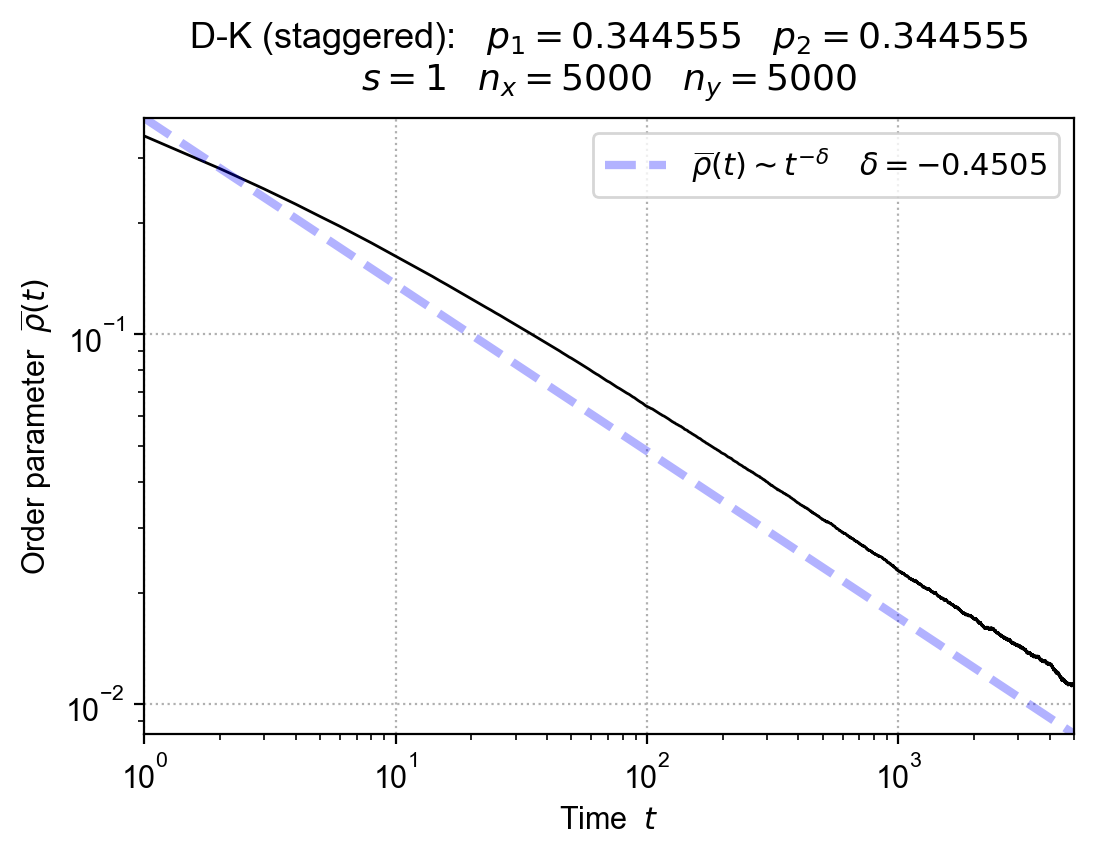

In [12]:
δ = 0.45051
# scale = 0.38

match parameters.growth_scheme:
    case GrowthScheme.Staggered:
        scale = 0.385
    case GrowthScheme.Simple:
        scale = 0.28

name = make_name(parameters, "ρmean", None, )
print(name)
viz.lattice_statistic(
    name,
    make_title(parameters, None),
    parameters,
    tracking,
    choices=("time", "ρ_mean"),
    labels=(
        "Order parameter  $\\widebar{\\rho}(t)$", 
        "$\\widebar{\\rho}(t) \\sim t^{-\\delta}$",
        "${\\delta}$",
    ),
    exponent=-δ, 
    scale=scale,
    i_offset=1,
    do_ref_curve=True,
)
plt.show()

In [13]:
i_offset: int = parameters.n_iterations//25
t: NDArray = tracking["time"][i_offset:]
ρ_mean: NDArray = tracking["ρ_mean"][i_offset:]
(exponent, scale, r_value, p_value, std_err) \
    = linregress(np.log(t), np.log(ρ_mean))
print(f"t range: {t[0]}-{t[-1]}")
print(f"Estimated t-decay exponent:  δ = {exponent:0.3f}")

t range: 200.0-5000.0
Estimated t-decay exponent:  δ = -0.444


### Mean square radius  $t$-decay

In [14]:
if parameters.initial_condition==InitialCondition.CentralCell:
    z = 1.766016
    # z = 1
    print(1/z)
    scale = 1

    name = make_name(parameters, "Rmean", None, )
    print(name)
    viz.lattice_statistic(
        name,
        make_title(parameters, None),
        tracking,
        choices=("time", "R_mean"),
        labels=(
            "Mean cluster radius  $\\widebar{R}(t)$", 
            "$\\widebar{R}(t) \\sim t^{1/z}$",
            "$1/z$",
        ),
        exponent=1/z, 
        scale=scale,
        i_offset=4,
        do_ref_curve=True,
    )
    plt.show()

<hr>

## Export

In [15]:
plots_dir: str = create_directories((os.path.curdir,"plots",), "dp2d")
export_plots(
    viz.fdict,
    plots_dir,
    "PNG",
    suffix="",
    dpi=150,
)

'././plots/dp2d'